# Problem Statement

In [14]:
"""
Goal:
Evaluate whether the redesigned checkout flow improves conversion and revenue metrics.
"""

'\nGoal:\nEvaluate whether the redesigned checkout flow improves conversion and revenue metrics.\n'

# Load Data

In [15]:
import pandas as pd

df = pd.read_csv("../data/experiment_data.csv")
df.head()

,user_id,group,device_type,country,session_time,converted,revenue
0,0,control,mobile,TW,270.017524,0,0.000000
1,1,variant,desktop,JP,321.536997,0,0.000000
2,2,control,mobile,US,317.491396,1,57.850099
3,3,control,desktop,JP,345.038757,0,0.000000
4,4,control,desktop,TW,271.043558,0,0.000000


In [16]:
##　Exploratory Analysis
df.groupby("group")["converted"].mean()

group
control    0.119290
variant    0.145378
Name: converted, dtype: float64

In [22]:
## Segmentation Analysis
device_conversion = df.groupby(
    ["device_type", "group"]
)["converted"].mean().reset_index()

device_conversion


,device_type,group,converted
0,desktop,control,0.104845
1,desktop,variant,0.149899
2,mobile,control,0.133868
3,mobile,variant,0.140924


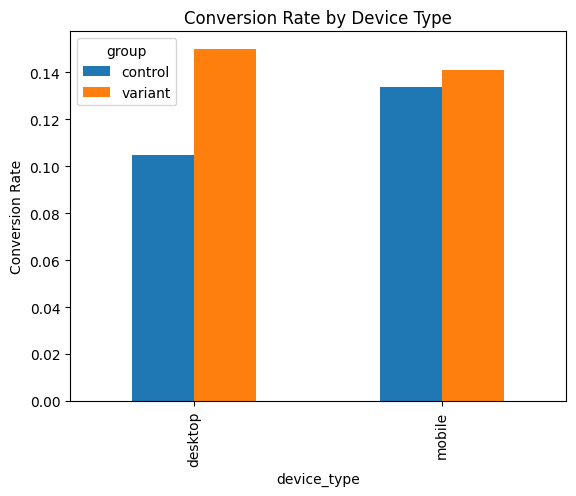

In [ ]:
import matplotlib.pyplot as plt

pivot_df = device_conversion.pivot(
    index="device_type",
    columns="group",
    values="converted"
)

pivot_df.plot(kind="bar")

plt.title("Conversion Rate by Device Type")
plt.ylabel("Conversion Rate")
plt.show()

'''
Insights:

- Desktop users experienced the largest uplift in conversion rate
- The redesigned checkout flow appears to reduce friction more effectively on desktop devices
- Mobile users showed smaller gains, potentially due to already optimized baseline performance

Business Recommendation:

- Prioritize desktop rollout
- Continue investigating mobile optimization opportunities
'''

In [ ]:
device_rates = df.groupby(
    ["device_type", "group"]
)["converted"].mean().unstack()

device_rates["uplift"] = (
    (device_rates["variant"] - device_rates["control"])
    / device_rates["control"]
)

device_rates

'''
Desktop users showed ~43% relative uplift in conversion rate,
significantly higher than mobile users.

This suggests the redesigned checkout flow had a much stronger
impact on desktop usability and user behavior.
'''

group,control,variant,uplift
device_type,,,
desktop,0.104845,0.149899,0.429718
mobile,0.133868,0.140924,0.052707


In [18]:
## Revenue Analysis
df.groupby("group")["revenue"].mean()

group
control    15.060747
variant    17.702826
Name: revenue, dtype: float64

# Metrics

Z-stat: 3.84987714997519
P-value: 0.00011817708366321765
Uplift: 0.21869536379871946


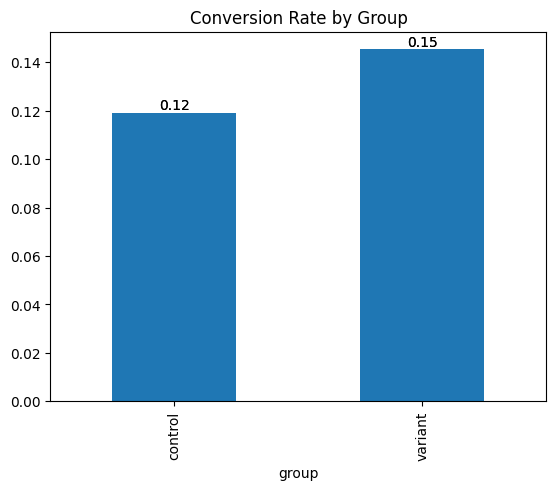

In [27]:
df.groupby("group").agg({
    "user_id": "count",
    "converted": "sum"
}).rename(columns={"user_id": "users", "converted": "conversions"})

## Statistical Test

from statsmodels.stats.proportion import proportions_ztest

count = [
    df[df.group=="variant"]["converted"].sum(),
    df[df.group=="control"]["converted"].sum()
]
nobs = [
    len(df[df.group=="variant"]),
    len(df[df.group=="control"])
]
z_stat, p_value = proportions_ztest(count, nobs)

print("Z-stat:", z_stat)
print("P-value:", p_value)

# Effect Size Calculation
control_rate = df[df.group=="control"]["converted"].mean()
variant_rate = df[df.group=="variant"]["converted"].mean()

uplift = (variant_rate - control_rate) / control_rate

print("Uplift:", uplift)

## Visualization
conversion = df.groupby("group")["converted"].mean()
conversion.plot(kind="bar")
ax = conversion.plot(kind="bar")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", label_type="edge")

plt.title("Conversion Rate by Group")
plt.show()

In [ ]:
"""
Desktop users showed ~43% relative uplift in conversion rate,
significantly higher than mobile users.

This suggests the redesigned checkout flow had a much stronger
impact on desktop usability and user behavior.
"""

'\nConclusion:\n\n- Variant group shows higher conversion rate\n- Statistical test indicates significance (p < 0.05)\n- Recommend rolling out the new design\n'